# SAR Prediction with TabPFN
### Nanoparticle Dataset — Full ML Workflow

This notebook follows a structured ML pipeline:
1. **Setup** — installs & imports
2. **Data loading** — read and clean raw data
3. **Exploratory data analysis** — understand the data before touching it
4. **Train / val / test split** — lock the test set away first
5. **Preprocessing** — encode, impute, scale (fit on train only)
6. **Feature engineering** — domain-informed features
7. **Model training** — TabPFN fit
8. **Evaluation** — metrics, plots, residuals, SHAP

---
## 1. Setup

In [ ]:
# Install dependencies (run once)
%pip install tabpfn shap xgboost missforest openpyxl joblib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.5 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,PowerTransformer,QuantileTransformer,MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import r2_score, mean_squared_error
from missforest import MissForest
from tabpfn import TabPFNRegressor
import shap as s
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import cross_val_predict
from scipy.optimize import differential_evolution
from scipy.spatial.distance import cdist
from itertools import combinations
import random
from joblib import Parallel, delayed
import multiprocessing

# Reproducibility
RANDOM_STATE = 62

# Column config — centralised so changes propagate everywhere
TARGET_COL   = 'f_SAR_W_g'
CAT_COLS      = ['c_shape_type', 'c_magnetic_phase', 'c_coating']
DROP_COLS     = ['-', 'DOI', 'c_core_composition', 'c_dopant_element', 'f_dopant_ratio']
FEATURE_NAMES = [
    'f_avg_core_width_nm', 'f_Ms_emu_g_MNP', 'f_Hc_Oe', 'is_doped',
    'c_coating', 'f_H_Oe', 'f_FCY_kHz', 'f_conc_MNP_mg_mL',
    'c_shape_type', 'c_magnetic_phase', 'f_avg_core_sd_nm _BOTH',
    'Ca_comp', 'Co_comp', 'Cu_comp', 'Fe_comp', 'Ga_comp', 'Gd_comp',
    'Mg_comp', 'Mn_comp', 'Nd_comp', 'Ni_comp', 'Sn_comp', 'Tb_comp',
    'Zn_comp', 'f_magnetic_anisotropy', 'f_magnetic_dipole_moment',
]

---
## 2. Data Loading

Read the raw Excel file, strip invisible Unicode characters from column names, and drop columns that carry no predictive signal (identifiers, DOIs).

In [ ]:
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        c.replace('\ufeff', '').replace('\u200b', '').strip()
        for c in df.columns
    ]
    return df


df_raw = pd.read_excel("Final.xlsx")
df_raw = clean_column_names(df_raw)

# Drop identifier/non-feature columns that exist in this dataset
cols_to_drop = [c for c in DROP_COLS if c in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop)

print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded 1548 rows × 32 columns


,f_avg_core_width_nm,f_Ms_emu_g_MNP,f_Hc_Oe,is_doped,f_is_coated,f_is_organic,f_is_inorganic,f_is_composite_coating,c_coating,f_H_Oe,...,Fe_comp,Ga_comp,Gd_comp,Mg_comp,Mn_comp,Nd_comp,Ni_comp,Sn_comp,Tb_comp,Zn_comp
0,15.0,60.00,0.0,0,0,0,0,0,NaN,600.00,...,3.00,0.0,0.00,0.0,0.0,0.0,0.0,0,0.0,0.0
1,17.0,36.78,6.0,1,1,1,0,0,Chitosan,187.42,...,2.93,0.0,0.07,0.0,0.0,0.0,0.0,0,0.0,0.0
2,75.0,60.00,100.0,0,0,0,0,0,NaN,300.00,...,3.00,0.0,0.00,0.0,0.0,0.0,0.0,0,0.0,0.0
3,19.9,53.10,4.0,0,1,1,0,0,TREG-coated,238.83,...,2.00,0.0,0.00,0.0,0.0,0.0,0.0,0,0.0,0.0
4,14.6,54.40,3.0,0,0,0,0,0,NaN,300.00,...,3.00,0.0,0.00,0.0,0.0,0.0,0.0,0,0.0,0.0


---
## 3. Exploratory Data Analysis

Understand distributions, missing values, and class balance **before** any modelling decisions. Insight here informs preprocessing choices.

In [ ]:
# --- 3a. Basic shape and dtypes ---
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)

Shape: (1548, 32)

Dtypes:
f_avg_core_width_nm            float64
f_Ms_emu_g_MNP                 float64
f_Hc_Oe                        float64
is_doped                         int64
f_is_coated                      int64
f_is_organic                     int64
f_is_inorganic                   int64
f_is_composite_coating           int64
c_coating                       object
f_H_Oe                         float64
f_FCY_kHz                      float64
f_conc_MNP_mg_mL               float64
c_shape_type                    object
c_magnetic_phase                object
f_SAR_W_g                      float64
f_avg_core_sd_nm _BOTH         float64
f_area_core_estimated_nm2      float64
f_volume_core_estimated_nm3    float64
f_area_volume_ratio            float64
Ca_comp                        float64
Co_comp                        float64
Cu_comp                        float64
Fe_comp                        float64
Ga_comp                        float64
Gd_comp                        float6

In [ ]:
# --- 3b. Missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(f"Columns with missing values ({len(missing_df)} of {df.shape[1]}):")
print(missing_df)

Columns with missing values (10 of 32):
                             missing_count  missing_%
f_avg_core_sd_nm _BOTH                 670       43.3
c_coating                              444       28.7
f_Hc_Oe                                243       15.7
f_area_volume_ratio                    211       13.6
f_area_core_estimated_nm2              211       13.6
f_volume_core_estimated_nm3            211       13.6
c_shape_type                           170       11.0
f_conc_MNP_mg_mL                       168       10.9
f_Ms_emu_g_MNP                         154        9.9
c_magnetic_phase                       141        9.1


In [ ]:
# --- 3d. Categorical column cardinality ---
for col in CAT_COLS:
    if col in df.columns:
        print(f"\n{col} ({df[col].nunique()} unique values):")
        print(df[col].value_counts(dropna=False).head(10))


c_shape_type (7 unique values):
c_shape_type
spherical         1167
NaN                170
nano_cube           83
octahedron          52
nano_flower         24
irregular           23
aggregate           18
semi_spherical      11
Name: count, dtype: int64

c_magnetic_phase (7 unique values):
c_magnetic_phase
superparamagnetic     1068
ferrimagnetic          217
NaN                    141
ferromagnetic           84
soft ferrimagnetic      22
soft ferromagnetic      13
Ferrimagnetic            2
paramagnetic             1
Name: count, dtype: int64

c_coating (122 unique values):
c_coating
NaN                                      444
none                                     137
PEG                                       82
protonated hydroxyl group due to pH 4     77
Oleic acid                                67
Citric acid                               66
Chitosan                                  62
oleic acid                                38
PVP                                       33
o

In [ ]:
# --- 3e. Numeric feature correlations with target ---
numeric_df = df.select_dtypes(include=np.number)
if TARGET_COL in numeric_df.columns:
    corr = numeric_df.corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
    print("Top correlations with target:")
    print(corr.head(15))

Top correlations with target:
f_Ms_emu_g_MNP                 0.309831
f_avg_core_width_nm            0.212310
f_area_volume_ratio           -0.157436
f_area_core_estimated_nm2      0.153174
f_H_Oe                         0.139183
f_FCY_kHz                      0.130932
Ca_comp                        0.108651
f_volume_core_estimated_nm3    0.108263
f_conc_MNP_mg_mL              -0.103827
f_is_inorganic                -0.071056
Cu_comp                        0.066102
f_is_organic                   0.053601
Tb_comp                        0.045630
f_Hc_Oe                       -0.041595
Mg_comp                       -0.037980
Name: f_SAR_W_g, dtype: float64


---
## 4. Train / Val / Test Split

Split **before** any preprocessing. The test set is locked away and never used to fit transformers or make tuning decisions. All imputers, encoders, and scalers are fit on `x_train` only.

In [ ]:
target_col = TARGET_COL.replace('\ufeff', '').replace('\u200b', '').strip()
X = df.drop(columns=[target_col])
y = df[target_col]

# 80 / 10 / 10 split
x_train, x_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"Train : {x_train.shape[0]} rows")
print(f"Val   : {x_val.shape[0]} rows")
print(f"Test  : {x_test.shape[0]} rows  ← locked until final evaluation")

Train : 1238 rows
Val   : 155 rows
Test  : 155 rows  ← locked until final evaluation


---
## 5. Preprocessing

All transformers are **fit on `x_train` only**, then applied to val and test.

Steps:
1. Engineer binary indicator flags from categorical columns
2. Fill categorical NaNs and ordinal-encode
3. Impute remaining numeric missing values (IterativeImputer)
4. Log-transform the target (right-skewed regression target)

In [ ]:
# --- 5a. Binary presence indicators (fit-free, safe to apply before split logic) ---
def add_presence_flags(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    df_out['f_is_coated']  = df_out['c_coating'].notna().astype(int)
    df_out['f_is_shaped']  = df_out['c_shape_type'].notna().astype(int)
    df_out['f_is_phased']  = df_out['c_magnetic_phase'].notna().astype(int)
    return df_out

x_train = add_presence_flags(x_train)
x_val   = add_presence_flags(x_val)
x_test  = add_presence_flags(x_test)

In [ ]:
# --- 5b. Categorical encoding ---
# Fill NaN → 'Unknown' for unseen categories, then ordinal-encode.
# Where the presence flag == 0 (field was missing), force the encoded value to -1.
# Encoders are fit on train only.

def encode_categorical(train_df, val_df, test_df, cat_col, flag_col):
    for df_part in [train_df, val_df, test_df]:
        df_part[cat_col] = df_part[cat_col].fillna('Unknown').astype(str)

    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train_df[cat_col] = enc.fit_transform(train_df[[cat_col]])
    val_df[cat_col]   = enc.transform(val_df[[cat_col]])
    test_df[cat_col]  = enc.transform(test_df[[cat_col]])

    for df_part in [train_df, val_df, test_df]:
        df_part.loc[df_part[flag_col] == 0, cat_col] = -1
        df_part.drop(columns=[flag_col], inplace=True)

    return train_df, val_df, test_df

x_train, x_val, x_test = encode_categorical(x_train, x_val, x_test, 'c_coating',       'f_is_coated')
x_train, x_val, x_test = encode_categorical(x_train, x_val, x_test, 'c_shape_type',    'f_is_shaped')
x_train, x_val, x_test = encode_categorical(x_train, x_val, x_test, 'c_magnetic_phase', 'f_is_phased')

print("Encoding done. x_train shape:", x_train.shape)

Encoding done. x_train shape: (1238, 30)


In [ ]:
# --- 5c. Numeric imputation (fit on train only) ---
numeric_cols = x_train.select_dtypes(include=np.number).columns.tolist()

imputer = MissForest(rgr=RandomForestRegressor(n_estimators=100,random_state=62),max_iter=10)

if x_train[numeric_cols].isnull().any().any():
    x_train[numeric_cols] = imputer.fit_transform(x_train[numeric_cols])
    x_val[numeric_cols]   = imputer.transform(x_val[numeric_cols])
    x_test[numeric_cols]  = imputer.transform(x_test[numeric_cols])
    print("Imputation applied.")
else:
    print("No missing values in numeric columns — skipping imputation.")

/usr/local/lib/python3.13/dist-packages/missforest/missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
 30%|███       | 3/10 [00:59<02:19, 19.89s/it]/usr/local/lib/python3.13/dist-packages/missforest/missforest.py:303: UserWarning: NRMSE increased.
  warnings.warn("NRMSE increased.")
/usr/local/lib/python3.13/dist-packages/missforest/missforest.py:453: UserWarning: Stopping criterion triggered during fitting. Before last imputation matrix will be returned.
  warnings.warn(
 30%|███       | 3/10 [01:19<03:05, 26.53s/it]
/usr/local/lib/python3.13/dist-packages/missforest/missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
/usr/local/lib/python3.13/dist

Imputation applied.


---
## 6. Feature Engineering

Domain-informed composite features, then quantile-normalise all inputs (fit on train only).

In [ ]:
# --- 6a. Feature scaling (QuantileTransformer, fit on train only) ---
transf = QuantileTransformer(random_state=RANDOM_STATE)

x_train_scaled = transf.fit_transform(x_train)
x_val_scaled   = transf.transform(x_val)
x_test_scaled  = transf.transform(x_test)

print("Scaling done. Train shape:", x_train_scaled.shape)

Scaling done. Train shape: (1238, 30)


In [ ]:
# --- 6b. Log transformation ---
y_train_log = np.log1p(y_train.values.astype(float))   # log1p on raw SAR
y_val_log   = np.log1p(y_val.values.astype(float))
y_test_log  = np.log1p(y_test.values.astype(float))

scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train_log.reshape(-1, 1)).flatten()
y_val_scaled   = scaler.transform(y_val_log.reshape(-1, 1)).flatten()
y_test_scaled  = scaler.transform(y_test_log.reshape(-1, 1)).flatten()

print("=== Scaler sanity check ===")
print(f"  data_min_ : {scaler.data_min_[0]:.4f}  "
      f"(= log1p({np.expm1(scaler.data_min_[0]):.2f} W/g)")
print(f"  data_max_ : {scaler.data_max_[0]:.4f}  "
      f"(= log1p({np.expm1(scaler.data_max_[0]):.2f} W/g)")
assert scaler.data_max_[0] > 1.0, \
    "Scaler data_max_ is still wrong — y_train may still be pre-transformed. Restart kernel and rerun top-to-bottom."

# Use these as your targets for model training (rename to match rest of notebook)
y_train = y_train_scaled
y_val   = y_val_scaled
y_test  = y_test_scaled


=== Scaler sanity check ===
  data_min_ : 0.1570  (= log1p(0.17 W/g)
  data_max_ : 8.6145  (= log1p(5510.00 W/g)


---
## 7. Model Training

TabPFN is a prior-fitted Bayesian neural network — it doesn't need hyperparameter search but does require a valid API token for datasets above the default size limit.

In [ ]:
# Set your TabPFN token.
# NEVER hardcode real API tokens in a notebook that goes into git.
# Preferred: set the TABPFN_TOKEN environment variable before launching Jupyter
# (e.g. `export TABPFN_TOKEN=...` or a .env file loaded outside this notebook).
# Fallback: prompt for it interactively so nothing sensitive is ever written to disk.
X = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
y = pd.Series(y_train, index=x_train.index)

if not os.environ.get("TABPFN_TOKEN"):
    os.environ["TABPFN_TOKEN"] = getpass("Enter your TabPFN API token (from tabpfn.com): ")
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

model = TabPFNRegressor(ignore_pretraining_limits=True)
model.fit(X, y)

print("Model trained.")


tabpfn-v3-regressor-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  233MB            

tabpfn-v3-regressor-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

Model trained.


---
## 8. Evaluation

Evaluate on **val** (for monitoring/tuning feedback) and **test** (final unbiased estimate). Test metrics are read once — do not loop back and re-tune based on them.

In [ ]:
x_val_scaled_df = pd.DataFrame(x_val_scaled, columns=x_train.columns)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x_train.columns)

y_val_pred  =  model.predict(x_val_scaled_df)
y_test_pred =  model.predict(x_test_scaled_df)
# Summary metrics
val_r2   = r2_score(y_val,  y_val_pred)
test_r2  = r2_score(y_test, y_test_pred)
val_rmse = np.sqrt(mean_squared_error(y_val,  y_val_pred))
test_rmse= np.sqrt(mean_squared_error(y_test, y_test_pred))

def inverse_sar(y_scaled: np.ndarray, fitted_scaler: MinMaxScaler) -> np.ndarray:
  y_scaled_clipped = np.clip(y_scaled, 0.0, 1.0)
  pred_log_units      = fitted_scaler.inverse_transform(y_scaled_clipped.reshape(-1, 1)).flatten()
  true_predicted_sar  = np.expm1(pred_log_units)
  return true_predicted_sar

y_test=inverse_sar(y_test,scaler)
y_test_pred=inverse_sar(y_test_pred,scaler)
err_90 = np.quantile(np.abs(y_test - y_test_pred), 0.90)

print(f"Validation  — R²: {val_r2:.4f}   RMSE: {val_rmse:.4f}")
print(f"Test        — R²: {test_r2:.4f}   RMSE: {test_rmse:.4f}")
print(f"90th-pct prediction error (test): ±{err_90:.4f}")

Validation  — R²: 0.7981   RMSE: 0.0753
Test        — R²: 0.8409   RMSE: 0.0636
90th-pct prediction error (test): ±80.1633


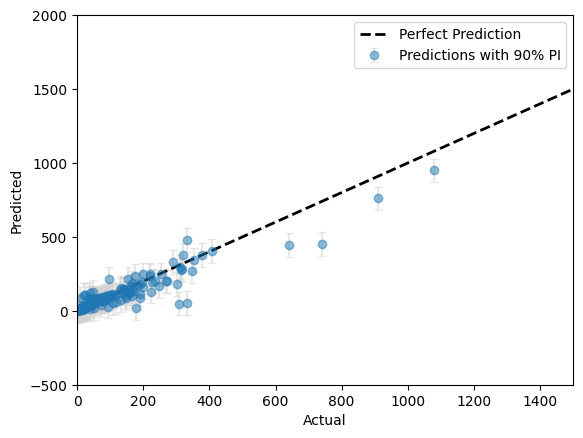

In [ ]:
plt.errorbar(y_test,y_test_pred, yerr=err_90, fmt='o', alpha=0.5, ecolor='lightgray', capsize=3, label='Predictions with 90% PI')
plt.plot([0, 1500], [0, 1500], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.xlim([0, 1500])
plt.ylim([-500, 2000])
plt.savefig('actual_vs_predicted_PI.png', dpi=150)
plt.show()

In [ ]:
# --- 8b. Actual vs Predicted ---
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_pred, y=y_true, alpha=0.6)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], 'r--', label='Ideal')
    plt.title(title)
    plt.xlabel('Predicted (log1p SAR)')
    plt.ylabel('Actual (log1p SAR)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{title}.png', dpi=150)
    plt.show()

plot_actual_vs_predicted(y_val,  y_val_pred,  'Validation — Actual vs Predicted')
plot_actual_vs_predicted(y_test, y_test_pred, 'Test — Actual vs Predicted')

In [ ]:
# --- 8c. Residual analysis ---
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Residual distribution (test set)')
axes[0].set_xlabel('Actual − Predicted')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

axes[1].scatter(y_test_pred, residuals, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Residuals vs Predicted (test set)')
axes[1].set_xlabel('Predicted (log1p SAR)')
axes[1].set_ylabel('Residual')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('Residuals.png', dpi=150)
plt.show()

In [ ]:
# SHAP Analysis using Kernel Explainer
background  = s.sample(x_train_scaled, 10)
explainer   = s.KernelExplainer(model.predict, background)
shap_values = explainer.shap_values(x_test_scaled)

shap_arr = shap_values[1] if isinstance(shap_values, list) else shap_values

imp_df = pd.DataFrame({
    'feature':    x_train.columns,
    'importance': np.abs(shap_arr).mean(axis=0),
}).sort_values('importance', ascending=False)

print("Feature importances (mean |SHAP|):")
print(imp_df.to_string(index=False))

In [ ]:
# SHAP summary plot
sns.barplot(imp_df, x='importance', y='feature', orient='h')
plt.title('SHAP Feature Importances')
plt.tight_layout()
plt.savefig('ShapSummary.png', dpi=150)
plt.show()

In [ ]:
features  = ['f_H_Oe', 'f_FCY_kHz', 'f_avg_core_width_nm', 'f_Ms_emu_g_MNP', 'is_doped']
dopant_cols  = [c for c in df.columns if c.endswith('_comp') and c != 'Fe_comp']
all_feats = features + dopant_cols

# Build an analysis dataframe from the training split only
train_df_raw = df.loc[x_train.index].copy()
train_df_raw[dopant_cols] = train_df_raw[dopant_cols].fillna(0)
train_df_raw['f_avg_core_width_nm'] = train_df_raw['f_avg_core_width_nm'].fillna(
    train_df_raw['f_avg_core_width_nm'].median())
train_df_raw = train_df_raw.dropna(subset=[target_col])

x = train_df_raw[all_feats]
y = train_df_raw[target_col]

train_df_raw['y_test_pred']= model.predict(x_train)

# LRT threshold classification
train_df_raw['H_kA_m']     = train_df_raw['f_H_Oe'] * 0.07958
train_df_raw['f_Hz']        = train_df_raw['f_FCY_kHz'] * 1000
train_df_raw['Hf_product']  = train_df_raw['H_kA_m'] * train_df_raw['f_Hz']
lrt_thresh = 5e6
train_df_raw['lrt'] = np.where(
    train_df_raw['Hf_product'] <= lrt_thresh, 'Low Field (LRT)', 'High Field')

train_df_raw['Freq_Range'] = pd.qcut(
    train_df_raw['f_FCY_kHz'], q=3, labels=['Low Freq', 'Mid Freq', 'High Freq'])

print(train_df_raw['lrt'].value_counts())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SAR vs Frequency
sns.scatterplot(data=train_df_raw, x='f_FCY_kHz', y='y_test_pred',
                hue='lrt', alpha=0.6, ax=axes[0])
sns.regplot(data=train_df_raw[train_df_raw['lrt'] == 'Low Field (LRT)'],
            x='f_FCY_kHz', y='y_test_pred',
            scatter=False, color='blue', order=1, ax=axes[0])
axes[0].set_title('Model SAR vs Frequency', fontweight='bold')
axes[0].set_xlabel('Frequency (kHz)')
axes[0].set_ylabel('Predicted SAR (W/g)')

# SAR vs H²
train_df_raw['H_squared'] = train_df_raw['f_H_Oe'] ** 2
sns.scatterplot(data=train_df_raw, x='H_squared', y='y_test_pred',
                hue='lrt', alpha=0.6, ax=axes[1])
sns.regplot(data=train_df_raw[train_df_raw['lrt'] == 'Low Field (LRT)'],
            x='H_squared', y='y_test_pred',
            scatter=False, color='blue', order=1, ax=axes[1])
axes[1].set_title('Model SAR vs H² (LRT: linear scaling)', fontweight='bold')
axes[1].set_xlabel('H² (Oe²)')
axes[1].set_ylabel('Predicted SAR (W/g)')

plt.suptitle('LRT Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lrt_analysis.png', dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df_raw, x='lrt', y='y_test_pred',
            hue='is_doped', palette='muted')
plt.title('Dopant Benefit: Low-Field vs High-Field Regimes', fontweight='bold')
plt.xlabel('Experimental Regime (H·f)')
plt.ylabel('Predicted SAR (W/g)')
plt.tight_layout()
plt.savefig('dopant_benefit.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=train_df_raw, x='Freq_Range', y='y_test_pred',
            hue='is_doped', palette='viridis', capsize=0.1)
plt.title('Dopant Performance Across Frequency Ranges', fontweight='bold')
plt.tight_layout()
plt.savefig('dopant_freq_range.png', dpi=150)
plt.show()

In [ ]:
cv_preds = cross_val_predict(model, X, y, cv=5)
train_df_raw['CV_Predicted'] = cv_preds
train_df_raw['Residual']     = y.values - cv_preds

# A: Actual vs CV Predicted
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=train_df_raw, x='CV_Predicted', y=target_col,
                alpha=0.6, color='purple', ax=ax)
ax.plot([y.min(), y.max()], [y.min(), y.max()],
        'k--', lw=2, label='Perfect Prediction')
ax.set_title('Actual vs CV-Predicted SAR', fontweight='bold')
ax.set_xlabel('Predicted SAR (W/g)')
ax.set_ylabel('Actual SAR (W/g)')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

In [ ]:
# B: Residuals vs core width  |  C: Residuals vs Ms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, xcol, color, xlabel in [
    (axes[0], 'f_avg_core_width_nm', 'teal', 'Average Core Width (nm)'),
    (axes[1], 'f_Ms_emu_g_MNP',      'blue', 'Ms (emu/g)'),
]:
    sns.scatterplot(data=train_df_raw, x=xcol, y='Residual',
                    alpha=0.6, color=color, ax=ax)
    ax.axhline(0, color='red', linestyle='--', lw=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Residual (Actual − Predicted)')

axes[0].set_title('Residuals vs Core Width', fontweight='bold')
axes[1].set_title('Residuals vs Saturation Magnetisation', fontweight='bold')

plt.tight_layout()
plt.savefig('residuals_vs_properties.png', dpi=300)
plt.show()

In [ ]:
# D: Residuals vs each dopant concentration
valid_dopants = [c for c in dopant_cols if (train_df_raw[c] > 0).sum() >= 3]
n_rows_d = int(np.ceil(len(valid_dopants) / 2))

fig, axes = plt.subplots(n_rows_d, 2, figsize=(14, n_rows_d * 4.5))
axes = np.array(axes).flatten()

for i, dc in enumerate(valid_dopants):
    ax = axes[i]
    sub = train_df_raw[train_df_raw[dc] > 0]
    sns.scatterplot(data=sub, x=dc, y='Residual', alpha=0.7, color='darkorange', ax=ax)
    ax.axhline(0, color='red', linestyle='--', lw=2)
    name = dc.replace('_comp', '')
    ax.set_title(f'Residuals vs {name}', fontweight='bold')
    ax.set_xlabel(f'{name} Concentration Ratio')
    ax.set_ylabel('Residual')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Residuals vs Individual Dopant Concentrations', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_vs_dopants.png', dpi=300, bbox_inches='tight')
plt.show()

err_thresh = train_df_raw['Residual'].abs().quantile(0.90)
high_err   = train_df_raw[train_df_raw['Residual'].abs() >= err_thresh]
print(f"Top-10% worst predictions:")
print(f"  Mean Core Width : {high_err['f_avg_core_width_nm'].mean():.2f} nm  "      f"(global: {train_df_raw['f_avg_core_width_nm'].mean():.2f} nm)")
print(f"  Mean Ms         : {high_err['f_Ms_emu_g_MNP'].mean():.2f} emu/g  "      f"(global: {train_df_raw['f_Ms_emu_g_MNP'].mean():.2f} emu/g)")

In [ ]:
X_pdp = pd.DataFrame(x_train_scaled, columns=x_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
PartialDependenceDisplay.from_estimator(
    model, X_pdp,
    features=['f_avg_core_width_nm', 'f_Ms_emu_g_MNP'],
    kind='both', subsample=50, ax=axes,
)
plt.suptitle('1D PDP: Core Width & Ms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pdp_1d.png', dpi=300)
plt.show()

In [ ]:
pairs = [
    ('f_avg_core_width_nm', 'f_Ms_emu_g_MNP', 'Core Width vs Ms'),
    ('f_avg_core_width_nm', 'f_H_Oe',          'Core Width vs H'),
    ('f_avg_core_width_nm', 'f_FCY_kHz',       'Core Width vs Frequency'),
    ('f_H_Oe',              'f_Ms_emu_g_MNP', 'H_Oe vs Ms'),
    ('f_H_Oe',              'f_FCY_kHz',       'H_Oe vs Frequency'),
     ('f_Ms_emu_g_MNP',  'f_FCY_kHz' , 'Ms VS Frequency')
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 11))
axes_flat = axes.flatten()

for idx, (feat_a, feat_b, title) in enumerate(pairs):
    ax = axes_flat[idx]

    try:
        PartialDependenceDisplay.from_estimator(
            model,
            X_pdp,
            features=[(feat_a, feat_b)],
            kind='average',
            ax=ax,
            grid_resolution=20
        )
        ax.set_title(f'2D PDP: {title}', fontsize=12, fontweight='bold', pad=10)

    except ValueError as e:
        print(f"Skipping plot for ({feat_a}, {feat_b}) due to error: {e}")
        ax.set_visible(False)

if len(pairs) < len(axes_flat):
    for unused_ax in axes_flat[len(pairs):]:
        fig.delaxes(unused_ax)

plt.suptitle('2D Partial Dependence Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('pdp_2d_all_pairs_subplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def inverse_sar(y_scaled: np.ndarray, fitted_scaler: MinMaxScaler) -> np.ndarray:
  y_scaled_clipped = np.clip(y_scaled, 0.0, 1.0)
  pred_log_units      = fitted_scaler.inverse_transform(y_scaled_clipped.reshape(-1, 1)).flatten()
  true_predicted_sar  = np.expm1(pred_log_units)
  return true_predicted_sar


predicted_sar=inverse_sar(y_test_pred,scaler)
actual_sar=inverse_sar(y_test,scaler)

print("=== True Physical Scale Sanity Check ===")
print(f"Original Data Max: {actual_sar.max():.4f} W/g")
print(f"Predicted Data Max: {predicted_sar.max():.4f} W/g")


df_results = x_test.copy()

df_results['Predicted_SAR_W_g'] = predicted_sar
df_results['Actual_SAR_W_g']    = actual_sar
print("\n=== Predicted SAR (W/g) ===")
print(f"  min  : {predicted_sar.min():.2f}")
print(f"  max  : {predicted_sar.max():.2f}")
print(f"  mean : {predicted_sar.mean():.2f}")

min = transf.transform(transf.quantiles_[0].reshape(1, -1))[0, 0]
max = transf.transform(transf.quantiles_[-1].reshape(1, -1))[0, 0]
print(f"Safe clipping range: [{min}, {max}]")
x_test_bounded=np.clip(x_test_scaled,min,max)

df_phys = pd.DataFrame(
    transf.inverse_transform(x_test_bounded),
    columns=x_test.columns,
    index=x_test.index
)

IMPORTANT_PROPS = [p for p in [
    "f_avg_core_width_nm", "f_Ms_emu_g_MNP", "f_Hc_Oe",
    "f_H_Oe", "f_FCY_kHz", "f_conc_MNP_mg_mL",
    "f_magnetic_anisotropy", "f_magnetic_dipole_moment","Ca_comp", "Co_comp", "Cu_comp", "Fe_comp", "Ga_comp", "Gd_comp",
    "Mg_comp", "Mn_comp", "Nd_comp", "Ni_comp", "Sn_comp", "Tb_comp",
    "Zn_comp",
] if p in df_results.columns]

for prop in IMPORTANT_PROPS:
    if prop in df_phys.columns:
        df_results[prop] = df_phys[prop]

df_results["Predicted_SAR_W_g"] = predicted_sar
df_results["Actual_SAR_W_g"]    = actual_sar


top50 = (
    df_results
    .sort_values("Predicted_SAR_W_g", ascending=False)
    .head(50)
    .reset_index(drop=True)
)

print("\n=== Top 50 Predicted SARs (W/g) ===")
print(top50[IMPORTANT_PROPS +["Predicted_SAR_W_g", "Actual_SAR_W_g"]].to_string())

summary = top50[IMPORTANT_PROPS + ["Predicted_SAR_W_g"]].describe()

print(summary.loc[["min", "25%", "50%", "mean", "75%", "max"]].round(2).to_string())

recipe = summary.loc[["25%", "75%"], IMPORTANT_PROPS].T
recipe.columns = ["Lower bound", "Upper bound"]
print(recipe.round(2).to_string())

top50.to_csv("top50_high_SAR_predictions.csv", index=False)
summary.to_excel("top50_high_SAR_summary.xlsx")
recipe.to_excel("top50_high_SAR_recipe.xlsx")
print("\nSaved → top50_high_SAR_predictions.csv")

In [ ]:
OPT_VARS = [
    "f_avg_core_width_nm",
    "f_Ms_emu_g_MNP",
    "f_Hc_Oe",
    "f_H_Oe",
    "f_FCY_kHz",
    "Zn_comp", "Co_comp", "Ca_comp", "Cu_comp", "Ni_comp",   # Fe_comp removed -- now derived
]

BOUNDS = [
    (5.0, 30.0),      # f_avg_core_width_nm
    (60.0, 150.0),    # f_Ms_emu_g_MNP
    (0.0, 100.0),     # f_Hc_Oe
    (5.0, 300.0),     # f_H_Oe
    (100.0, 500.0),   # f_FCY_kHz
    (0.05, 0.20),        # Zn_comp
    (0.05, 0.20),        # Co_comp
    (0.05, 0.20),        # Ca_comp
    (0.05, 0.20),        # Cu_comp
    (0.05, 0.20)        # Ni_comp
    # Fe_comp is no longer a free DE dimension
]

DIRECTION_WEIGHTS = {
    "f_avg_core_width_nm": -1.0,   # minimize core width
    "f_Hc_Oe":             -1.0,   # minimize coercivity
    "f_FCY_kHz":           -1.0,   # minimize applied frequency
    "f_Ms_emu_g_MNP":      +1.0,   # maximize saturation magnetization
    "f_H_Oe":               +1.0,  # maximize applied field
}

TARGET_WEIGHT   = 15.0
SAR_SCALE       = 2000.0
DOPANT_COLS     = ["Zn_comp", "Co_comp", "Ca_comp", "Cu_comp", "Ni_comp", "Fe_comp"]
MAX_DOPANT_SUM  = 3.0
LRT_HF_LIMIT    = 5.0e9
OE_TO_A_M       = 79.577
CONSTRAINT_PENALTY = 50.0

N_CANDIDATES     = 20
DIVERSITY_RADIUS = 0.5
DIVERSITY_LAMBDA = 1.0
POPSIZE          = 20
MAXITER          = 150

OPT_IDX  = {name: i for i, name in enumerate(OPT_VARS)}
H_IDX    = OPT_IDX["f_H_Oe"]
F_IDX    = OPT_IDX["f_FCY_kHz"]
DOPANT_IDXS = [OPT_IDX[c] for c in DOPANT_COLS if c in OPT_IDX]
FREE_DOPANT_COLS = ["Zn_comp", "Co_comp", "Ca_comp", "Cu_comp", "Ni_comp"]
FE_COL           = "Fe_comp"
FE_BOUNDS        = (1.0, 3.0)
DOPANT_SUM_TARGET = 3.0
FREE_DOPANT_IDXS = [OPT_IDX[c] for c in FREE_DOPANT_COLS]



BOUNDS_ARR = np.array(BOUNDS)
BOUNDS_LO  = BOUNDS_ARR[:, 0]
BOUNDS_HI  = BOUNDS_ARR[:, 1]

def normalize(X):
    return (X - BOUNDS_LO) / (BOUNDS_HI - BOUNDS_LO + 1e-8)

def compute_fe_comp(X: np.ndarray) -> np.ndarray:
    return DOPANT_SUM_TARGET - X[:, FREE_DOPANT_IDXS].sum(axis=1)

def make_baseline_row(X_raw: pd.DataFrame, mode: str = "median") -> pd.DataFrame:
    row = X_raw.iloc[[0]].copy()
    for col in X_raw.columns:
        if pd.api.types.is_numeric_dtype(X_raw[col]):
            row[col] = X_raw[col].median() if mode == "median" else X_raw[col].iloc[0]
        else:
            row[col] = X_raw[col].mode().iloc[0] if mode == "median" else X_raw[col].iloc[0]
    return row

def batch_predict_sar(X: np.ndarray, model, transf, y_scaler,
                       baseline_row_raw: pd.DataFrame, feature_names,
                       numeric_cols, opt_vars=OPT_VARS) -> np.ndarray:
    n = X.shape[0]
    batch = pd.concat([baseline_row_raw] * n, ignore_index=True)
    for j, name in enumerate(opt_vars):
        batch[name] = X[:, j]

    batch[FE_COL] = compute_fe_comp(X)

    batch[numeric_cols] = transf.transform(batch[numeric_cols])

    y_model = model.predict(batch[feature_names])
    y_log   = y_scaler.inverse_transform(y_model.reshape(-1, 1)).flatten()
    return np.expm1(y_log)


def objective_vectorized(X_T, model, transf, y_scaler, baseline_row_raw,
                          feature_names, numeric_cols, penalized_points,
                          debug=False):
    X = X_T.T
    n = X.shape[0]
    X_norm = normalize(X)

    sar = batch_predict_sar(X, model, transf, y_scaler, baseline_row_raw,
                             feature_names, numeric_cols)

    raw_structural_score = np.zeros(n)
    for name, weight in DIRECTION_WEIGHTS.items():
        i = OPT_IDX[name]
        raw_structural_score += -weight * X_norm[:, i]
    raw_structural_score /= len(DIRECTION_WEIGHTS)

    raw_sar_score = -TARGET_WEIGHT * (sar / SAR_SCALE)

    h_am = X[:, H_IDX] * OE_TO_A_M
    f_hz = X[:, F_IDX] * 1000.0
    hf_violation = np.maximum(0.0, (h_am * f_hz) - LRT_HF_LIMIT) / LRT_HF_LIMIT

    fe_comp = compute_fe_comp(X)
    fe_lo, fe_hi = FE_BOUNDS
    fe_violation = (np.maximum(0.0, fe_lo - fe_comp) +
                     np.maximum(0.0, fe_comp - fe_hi)) / (fe_hi - fe_lo)

    penalty = CONSTRAINT_PENALTY * (hf_violation + fe_violation)

    score = raw_structural_score + raw_sar_score + penalty

    diversity_term = np.zeros(n)
    if penalized_points:
        P = np.array(penalized_points)
        P_norm = normalize(P)
        dists = cdist(X_norm, P_norm)
        proximity = np.exp(-(dists ** 2) / (2 * DIVERSITY_RADIUS ** 2)).sum(axis=1)
        diversity_term = DIVERSITY_LAMBDA * proximity
        score = score + diversity_term

    if debug:
        print(f"  structural: mean={raw_structural_score.mean():+.3f} | "
              f"sar: mean={raw_sar_score.mean():+.3f} | "
              f"hf_pen: mean={hf_violation.mean():+.3f} | "
              f"fe_pen: mean={fe_violation.mean():+.3f} | "
              f"diversity: mean={diversity_term.mean():+.3f}")

    return score

from itertools import combinations
import random

FREE_DOPANT_COLS = ["Zn_comp", "Co_comp", "Ca_comp", "Cu_comp", "Ni_comp"]
FE_COL           = "Fe_comp"
FE_BOUNDS        = (1.0, 3.0)
DOPANT_SUM_TARGET = 3.0

FREE_DOPANT_IDXS = [OPT_IDX[c] for c in FREE_DOPANT_COLS]

def make_bounds_for_mask(active_names, base_bounds=BOUNDS):
    bounds = list(base_bounds)
    for name in FREE_DOPANT_COLS:
        i = OPT_IDX[name]
        if name in active_names:
            # Preserve lower and upper bounds from base_bounds (e.g., 0.05 to 0.20)
            bounds[i] = base_bounds[i]
        else:
            # Pin inactive dopants to 0
            bounds[i] = (0.0, 0.0)
    return bounds

def optimize_for_subset(active_names, model, transf, y_scaler, feature_names, numeric_cols,
                         baseline_row_raw, n_candidates=N_CANDIDATES, seed_offset=0):
    bounds = make_bounds_for_mask(active_names)   # zeros out inactive dopant dims
    penalized_points = []
    rows = []

    for i in range(n_candidates):
        result = differential_evolution(
            objective_vectorized,
            bounds=bounds,
            args=(model, transf, y_scaler, baseline_row_raw, feature_names,
                  numeric_cols, penalized_points),
            vectorized=True,
            updating="deferred",
            popsize=POPSIZE,
            maxiter=MAXITER,
            tol=1e-7,
            mutation=(0.4, 1.0),
            recombination=0.7,
            polish=False,
            seed=RANDOM_STATE + seed_offset + i,
        )
        best_x = result.x
        penalized_points.append(best_x)

        pred_sar = batch_predict_sar(
            best_x.reshape(1, -1), model, transf, y_scaler,
            baseline_row_raw, feature_names, numeric_cols
        )[0]

        fe_comp = float(compute_fe_comp(best_x.reshape(1, -1))[0])
        dopant_sum = float(best_x[FREE_DOPANT_IDXS].sum() + fe_comp)  # should ≈ DOPANT_SUM_TARGET
        hf_product = float(best_x[H_IDX] * OE_TO_A_M * best_x[F_IDX] * 1000.0)
        fe_ok = FE_BOUNDS[0] <= fe_comp <= FE_BOUNDS[1]

        row = dict(zip(OPT_VARS, best_x))
        row["Fe_comp"] = fe_comp
        row["Predicted_SAR_W_g"] = pred_sar
        row["Dopant_Sum"] = dopant_sum
        row["Hf_product"] = hf_product
        row["Active_Dopants"] = "+".join(active_names)
        row["Constraint_Satisfied"] = bool(hf_product <= LRT_HF_LIMIT and fe_ok)
        rows.append(row)

        print(f"Candidate {i+1:2d}/{n_candidates} [{'+'.join(active_names)}] | "
              f"Predicted SAR = {pred_sar:8.2f} W/g | "
              f"Dopant Sum = {dopant_sum:.4f} | Fe_comp = {fe_comp:.3f} "
              f"(bounds {FE_BOUNDS}) | "
              f"H*f = {hf_product:.3e} (limit {LRT_HF_LIMIT:.1e}) | "
              f"OK={row['Constraint_Satisfied']}")

    out = pd.DataFrame(rows).sort_values("Predicted_SAR_W_g", ascending=False).reset_index(drop=True)
    return out


def optimize_across_dopant_subsets(model, transf, y_scaler, feature_names, numeric_cols,
                                    baseline_row_raw, subset_sizes=(2, 3, 5),
                                    max_subsets_per_size=8, n_candidates_per_subset=3):
    all_results = []
    seed_offset = 0
    random.seed(RANDOM_STATE)

    for size in subset_sizes:
        subsets = list(combinations(FREE_DOPANT_COLS, size))
        if len(subsets) > max_subsets_per_size:
            subsets = random.sample(subsets, max_subsets_per_size)

        for active_names in subsets:
            print(f"\n--- Optimizing subset: {'+'.join(active_names)} "
                  f"({size} active dopant(s) + Fe) ---")
            df = optimize_for_subset(list(active_names), model, transf, y_scaler,
                                      feature_names, numeric_cols, baseline_row_raw,
                                      n_candidates_per_subset, seed_offset)
            all_results.append(df)
            seed_offset += n_candidates_per_subset

    out = pd.concat(all_results, ignore_index=True)
    out = out.sort_values("Predicted_SAR_W_g", ascending=False).reset_index(drop=True)
    return out

In [ ]:
baseline_row = make_baseline_row(x_train, mode="median")
feature_names = x_train.columns.tolist()

top20 = optimize_across_dopant_subsets(
    model=model,
    transf=transf,
    y_scaler=scaler,
    feature_names=feature_names,
    numeric_cols=numeric_cols,
    baseline_row_raw=baseline_row,
    subset_sizes=(2,3,4,5),
    max_subsets_per_size=10,
    n_candidates_per_subset=3,
)

In [ ]:
DOPANT_COLS = ["Zn_comp", "Co_comp", "Ca_comp", "Cu_comp", "Ni_comp", "Fe_comp"]

def format_composition(row):
    parts = []
    for dopant in FREE_DOPANT_COLS:
        val = row[dopant]
        if val > 0:
            symbol = dopant.replace("_comp", "")
            parts.append(f"{symbol}{val:.2f}")
    parts.append(f"Fe{row['Fe_comp']:.2f}")
    return "".join(parts) + "O4"

top20["Composition"] = top20.apply(format_composition, axis=1)

cols_to_show = (OPT_VARS + ["Fe_comp", "Composition", "Predicted_SAR_W_g",
                             "Dopant_Sum", "Hf_product", "Constraint_Satisfied"])
print(top20[cols_to_show].round(3).to_string())

n_ok = int(top20["Constraint_Satisfied"].sum())
print(f"\n{n_ok}/{len(top20)} candidates satisfy the LRT safety limit and dopant-sum constraint.")

top20.to_excel("top_candidates_tabpfn.xlsx", index=False)

In [ ]:
# Optional: only relevant when running in Google Colab.
# Locally / in CI this cell is a no-op — the file is already saved by the
# previous cell (top_candidates_tabpfn.xlsx) via the standard filesystem.
try:
    from google.colab import files
    files.download('top_candidates_tabpfn.xlsx')
except ImportError:
    print("Not running in Google Colab — skipping browser download. "
          "File already saved to top_candidates_tabpfn.xlsx in the working directory.")
